In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)
print(torch.cuda.get_arch_list())


True
NVIDIA GeForce RTX 5080
12.8
['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# seed = 2
# torch.manual_seed(seed)
# np.random.seed(seed)
#
# torch.cuda.manual_seed(seed)
# torch.cuda.manual_seed_all(seed)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

In [4]:
vi_features = ['ndvi_noir_rgb_method', 'gndvi_noir_rgb_method', 'rdvi_noir_rgb_method', 'savi_noir_rgb_method', 'sr_noir_rgb_method','evi_noir_rgb_method', 'cigreen_noir_rgb_method' , 'gli', 'vari']
# weather_features = ['Solar', 'Precipitation', 'AirTemp', 'Vapor_Pressure', 'AtmPressure', 'RelHumidity']
weather_features = []
canopy_temp_features = ['lepton_mean_temp', 'lepton_min_temp', 'lepton_max_temp']
# canopy_temp_features = []

features = vi_features + canopy_temp_features + weather_features
output_variable = 'GYLD_kg_m3'


Text(0.5, 1.0, 'Train vs Test Yield Distribution')

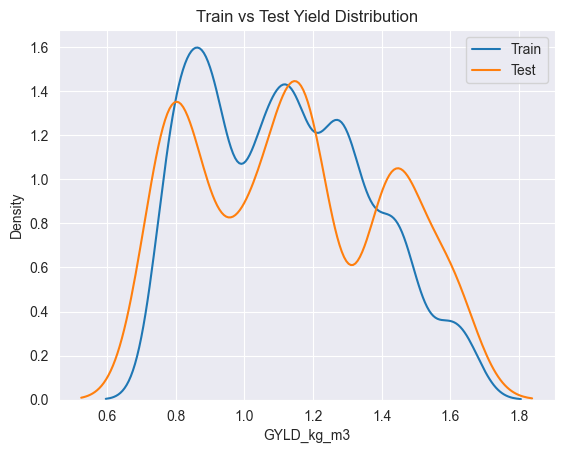

In [5]:
# Loading saved training test
train_df = pd.read_excel("data/stratified_train_test_datasets_v3.xlsx", sheet_name='Train')
test_df = pd.read_excel("data/stratified_train_test_datasets_v3.xlsx", sheet_name='Test')

sns.kdeplot(train_df[output_variable], label='Train')
sns.kdeplot(test_df[output_variable], label='Test')
plt.legend()
plt.title("Train vs Test Yield Distribution")

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

scaler_X = StandardScaler()
scaler_y = RobustScaler()

# Fit on training features and yield only
scaler_X.fit(train_df[features])
scaler_y.fit(train_df[[output_variable]])

train_df_scaled = train_df.copy()
test_df_scaled  = test_df.copy()

# --- Scaled features and target variable---
train_df_scaled[features] = scaler_X.transform(train_df[features])
train_df_scaled[output_variable] = scaler_y.transform(train_df[[output_variable]])

test_df_scaled[features] = scaler_X.transform(test_df[features])
test_df_scaled[output_variable] = scaler_y.transform(test_df[[output_variable]])

In [7]:

num_na_rows = train_df_scaled.isna().any(axis=1).sum()
print(f"train_df_scaled Rows with at least one NaN: {num_na_rows}")

num_na_rows = test_df_scaled.isna().any(axis=1).sum()
print(f"test_df_scaled Rows with at least one NaN: {num_na_rows}")


train_df_scaled Rows with at least one NaN: 1167
test_df_scaled Rows with at least one NaN: 364


In [ ]:
# print(X_test_scaled.shape)

In [8]:
def train_data(model, model_train_loader, num_epochs, learning_rate, weight_decay, hyper_param_criterion_method, file_save_name, early_stopping = False):
    best_train_loss  = float('inf')
    patience = 20
    counter = 0

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )
    if hyper_param_criterion_method == "MSE":
        criterion = nn.MSELoss()
    else:
        criterion = nn.SmoothL1Loss(beta=1)

    total_loss = []
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch, lengths in model_train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            lengths = lengths.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch, lengths)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            # Gradient clipping (prevents exploding gradients)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)

        avg_loss = train_loss / len(model_train_loader.dataset)
        total_loss.append(avg_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_loss:.5f}")

        if train_loss < best_train_loss:
            best_train_loss = train_loss
            if file_save_name != "":
                torch.save(model.state_dict(), file_save_name)
            counter = 0
        elif early_stopping:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break
    return total_loss


In [9]:
from sklearn.metrics import  mean_squared_error

def evaluate_model(model, val_loader, output_variable_scaler, doInverseTransformScale = False, plot_pred_vs_true = False):

    model.eval()  # set model to evaluation mode
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch, lengths in val_loader:
            X_batch = X_batch.to(device)
            lengths = lengths.to(device)
            y_hat = model(X_batch, lengths)

            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()

    if doInverseTransformScale:
        y_true = output_variable_scaler.inverse_transform(y_true)
        y_pred = output_variable_scaler.inverse_transform(y_pred)

    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)

    if plot_pred_vs_true:
        plt.figure(figsize=(8,6))
        plt.scatter(y_true, y_pred, alpha=0.7)
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--')
        plt.xlabel("Actual Yield")
        plt.ylabel("Predicted Yield")
        plt.title("LSTM Predictions vs Actual")
        plt.show()

    return r2, mse

In [10]:
window_size = 30
pad_value = 0

In [11]:


cols_to_pad = canopy_temp_features
train_df_scaled[cols_to_pad] = train_df_scaled[cols_to_pad].fillna(pad_value)
test_df_scaled[cols_to_pad] = test_df_scaled[cols_to_pad].fillna(pad_value)


In [12]:
from torch.nn.utils.rnn import pack_padded_sequence
from helper import make_progressive_windows
from vi_dataset import VIDataset
from model_definitions import  GRUModel
from torch.utils.data import DataLoader

def validation_with_test(trial_id, batch_size, epochs, hidden_size, num_layers, dropout, bidirectional, learning_rate, weight_decay, hyper_param_criterion_method):

    X_train_scaled, y_train_scaled, lengths_train  = make_progressive_windows(
            dataframe=train_df_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

    X_test_scaled, y_test_scaled, lengths_test = make_progressive_windows(
        dataframe=test_df_scaled,
        features=features,
        output_variable=output_variable,
        window_size=window_size,
        pad_value=pad_value)

    train_dataset = VIDataset(X_train_scaled, y_train_scaled, lengths_train)
    test_dataset = VIDataset(X_test_scaled, y_test_scaled, lengths_test)

    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader    = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = GRUModel(input_size = len(features), hidden_size = hidden_size, num_layers = num_layers,
                     output_size= 1 , dropout=dropout, bidirectional = bidirectional).to(device)

    train_data(
        model = model,
        model_train_loader= train_loader,
        num_epochs = epochs,
        learning_rate = learning_rate,
        weight_decay = weight_decay,
        hyper_param_criterion_method = hyper_param_criterion_method,
        file_save_name=f"best_model_hyper_param{trial_id}.pth",
        early_stopping=True
    )

    r2, mse = evaluate_model(
        model = model,
        val_loader = test_loader,
        output_variable_scaler=scaler_y)


    print(f" R²: {r2:.4f}")


    return r2

In [13]:
import optuna
from sklearn.metrics import r2_score

epochs = 1000

def objective2(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = validation_with_test(
        trial_id = trial.number,
        batch_size= batch_size,
        epochs=epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2

C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
study = optuna.create_study(direction="maximize")
study.optimize(objective2, n_trials=180)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)

[I 2025-11-13 18:24:03,953] A new study created in memory with name: no-name-b4a8b94d-8481-439f-bafc-23d4574326c8


Epoch [1/1000] - Train Loss: 0.16132
Epoch [2/1000] - Train Loss: 0.13569
Epoch [3/1000] - Train Loss: 0.12576
Epoch [4/1000] - Train Loss: 0.11815
Epoch [5/1000] - Train Loss: 0.11149
Epoch [6/1000] - Train Loss: 0.10316
Epoch [7/1000] - Train Loss: 0.09760
Epoch [8/1000] - Train Loss: 0.09092
Epoch [9/1000] - Train Loss: 0.08640
Epoch [10/1000] - Train Loss: 0.08147
Epoch [11/1000] - Train Loss: 0.07862
Epoch [12/1000] - Train Loss: 0.07298
Epoch [13/1000] - Train Loss: 0.06891
Epoch [14/1000] - Train Loss: 0.06761
Epoch [15/1000] - Train Loss: 0.06266
Epoch [16/1000] - Train Loss: 0.05987
Epoch [17/1000] - Train Loss: 0.06008
Epoch [18/1000] - Train Loss: 0.05472
Epoch [19/1000] - Train Loss: 0.05428
Epoch [20/1000] - Train Loss: 0.04940
Epoch [21/1000] - Train Loss: 0.04926
Epoch [22/1000] - Train Loss: 0.04853
Epoch [23/1000] - Train Loss: 0.04596
Epoch [24/1000] - Train Loss: 0.04249
Epoch [25/1000] - Train Loss: 0.04341
Epoch [26/1000] - Train Loss: 0.04275
Epoch [27/1000] - Tra

[I 2025-11-13 18:24:34,744] Trial 0 finished with value: 0.24145060777664185 and parameters: {'hidden_size': 8, 'num_layers': 3, 'dropout': 0.2597808344415148, 'lr': 0.0023331278064083107, 'weight_decay': 4.474482338222553e-10, 'batch_size': 64}. Best is trial 0 with value: 0.24145060777664185.


Epoch [259/1000] - Train Loss: 0.00956
Epoch [260/1000] - Train Loss: 0.00965
Early stopping triggered.
 R²: 0.2415
Epoch [1/1000] - Train Loss: 0.13218
Epoch [2/1000] - Train Loss: 0.09679
Epoch [3/1000] - Train Loss: 0.06309
Epoch [4/1000] - Train Loss: 0.04882
Epoch [5/1000] - Train Loss: 0.03649
Epoch [6/1000] - Train Loss: 0.02678
Epoch [7/1000] - Train Loss: 0.02917
Epoch [8/1000] - Train Loss: 0.02212
Epoch [9/1000] - Train Loss: 0.02063
Epoch [10/1000] - Train Loss: 0.01818
Epoch [11/1000] - Train Loss: 0.01738
Epoch [12/1000] - Train Loss: 0.01825
Epoch [13/1000] - Train Loss: 0.01530
Epoch [14/1000] - Train Loss: 0.01409
Epoch [15/1000] - Train Loss: 0.01172
Epoch [16/1000] - Train Loss: 0.02350
Epoch [17/1000] - Train Loss: 0.01897
Epoch [18/1000] - Train Loss: 0.01418
Epoch [19/1000] - Train Loss: 0.01243
Epoch [20/1000] - Train Loss: 0.01239
Epoch [21/1000] - Train Loss: 0.00951
Epoch [22/1000] - Train Loss: 0.00953
Epoch [23/1000] - Train Loss: 0.01232
Epoch [24/1000] - T

[I 2025-11-13 18:25:30,627] Trial 1 finished with value: 0.045979857444763184 and parameters: {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.3553574032372337, 'lr': 0.0035202263018419447, 'weight_decay': 1.644933345582044e-10, 'batch_size': 8}. Best is trial 0 with value: 0.24145060777664185.


...

Epoch [355/1000] - Train Loss: 0.02608
Early stopping triggered.
 R²: -0.2473
Epoch [1/1000] - Train Loss: 0.13852
Epoch [2/1000] - Train Loss: 0.12489
Epoch [3/1000] - Train Loss: 0.11257
Epoch [4/1000] - Train Loss: 0.10756
Epoch [5/1000] - Train Loss: 0.10293
Epoch [6/1000] - Train Loss: 0.09711
Epoch [7/1000] - Train Loss: 0.09581
Epoch [8/1000] - Train Loss: 0.09001
Epoch [9/1000] - Train Loss: 0.08663
Epoch [10/1000] - Train Loss: 0.08057
Epoch [11/1000] - Train Loss: 0.07818
Epoch [12/1000] - Train Loss: 0.07496
Epoch [13/1000] - Train Loss: 0.06915
Epoch [14/1000] - Train Loss: 0.07144
Epoch [15/1000] - Train Loss: 0.06590
Epoch [16/1000] - Train Loss: 0.06699
Epoch [17/1000] - Train Loss: 0.06093
Epoch [18/1000] - Train Loss: 0.05744
Epoch [19/1000] - Train Loss: 0.05784
Epoch [20/1000] - Train Loss: 0.05628
Epoch [21/1000] - Train Loss: 0.05250
Epoch [22/1000] - Train Loss: 0.05093
Epoch [23/1000] - Train Loss: 0.04792
Epoch [24/1000] - Train Loss: 0.04841
Epoch [25/1000] - T

[I 2025-11-13 21:15:35,819] Trial 178 finished with value: -0.03628873825073242 and parameters: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.12695448667494796, 'lr': 0.0010365837169387937, 'weight_decay': 0.0006848666630081941, 'batch_size': 32}. Best is trial 29 with value: 0.4216291904449463.


Epoch [183/1000] - Train Loss: 0.01614
Epoch [184/1000] - Train Loss: 0.01629
Early stopping triggered.
 R²: -0.0363
Epoch [1/1000] - Train Loss: 0.17817
Epoch [2/1000] - Train Loss: 0.17039
Epoch [3/1000] - Train Loss: 0.16173
Epoch [4/1000] - Train Loss: 0.15179
Epoch [5/1000] - Train Loss: 0.14718
Epoch [6/1000] - Train Loss: 0.14189
Epoch [7/1000] - Train Loss: 0.13957
Epoch [8/1000] - Train Loss: 0.13629
Epoch [9/1000] - Train Loss: 0.13590
Epoch [10/1000] - Train Loss: 0.13294
Epoch [11/1000] - Train Loss: 0.13269
Epoch [12/1000] - Train Loss: 0.13037
Epoch [13/1000] - Train Loss: 0.12980
Epoch [14/1000] - Train Loss: 0.12641
Epoch [15/1000] - Train Loss: 0.12671
Epoch [16/1000] - Train Loss: 0.12464
Epoch [17/1000] - Train Loss: 0.12404
Epoch [18/1000] - Train Loss: 0.12302
Epoch [19/1000] - Train Loss: 0.12112
Epoch [20/1000] - Train Loss: 0.12022
Epoch [21/1000] - Train Loss: 0.11859
Epoch [22/1000] - Train Loss: 0.11824
Epoch [23/1000] - Train Loss: 0.11871
Epoch [24/1000] - 

[I 2025-11-13 21:16:02,798] Trial 179 finished with value: 0.029434800148010254 and parameters: {'hidden_size': 8, 'num_layers': 3, 'dropout': 0.48648846476200647, 'lr': 0.00040720538661595464, 'weight_decay': 0.0002676315895647711, 'batch_size': 64}. Best is trial 29 with value: 0.4216291904449463.


Epoch [406/1000] - Train Loss: 0.04322
Early stopping triggered.
 R²: 0.0294
Best R²: 0.4216
Best hyperparameters: {'hidden_size': 8, 'num_layers': 3, 'dropout': 0.45863818572312726, 'lr': 0.0001015529310602788, 'weight_decay': 9.401388985791902e-10, 'batch_size': 16}


In [15]:
# =============================================
#  Train the best model with best hyper params
# =============================================
from model_definitions import GRUModel
# Best R²: 0.4483
# saved as /best_gru_models/best_model_hyper_param_1.pth
# Dataset: v2
# Features: Only the VIs in v2 dataset and lepton temp
# Masking/Length in GRU: False;  Make sure GRU model does not use lengths in the forward function
# Pad = -99
# criterion_method = L1 Loss
# best_gru_params =  {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.10344360354230203, 'lr': 0.0002476906474606584, 'weight_decay': 0.0005347879641161282, 'batch_size': 8}

# Best R²: 0.4605
# saved as /best_gru_models/best_model_hyper_param112.pth
# Dataset: v2
# Features: Only the VIs in v2 dataset and lepton temp
# Masking/Length in GRU: False;  Make sure GRU model does not use lengths in the forward function
# Pad = -99
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.03884806018039991, 'lr': 0.00042173321148857924, 'weight_decay': 0.0004972207591747834, 'batch_size': 64}


# Best R²: 0.4161
# saved as /best_gru_models/best_model_hyper_param_3.pth
# Dataset: v3
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: True;  Make sure GRU model use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.07420456457400194, 'lr': 0.00981026753766152, 'weight_decay': 8.506150589531528e-08, 'batch_size': 16}

# Best R²: 0.4455
# saved as /best_gru_models/best_model_hyper_param_4.pth
# Dataset: v3
# Features: All the VIs in v3 dataset and lepton temperature
# Masking/Length in GRU: False;  Make sure GRU model does not use lengths in the forward function
# Pad = -99
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 16, 'num_layers': 1, 'dropout': 0.07545645234219177, 'lr': 0.00038890561009715475, 'weight_decay': 0.0007797370352742492, 'batch_size': 16}


# Best R²: 0.18 not good
# Dataset: v3
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: True;  Make sure GRU model use lengths in the forward function
# Pad = -99
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 8, 'num_layers': 2, 'dropout': 0.01882176215855477, 'lr': 0.007580682214882081, 'weight_decay': 1.416934618280146e-06, 'batch_size': 64}

# Best R²: 0.2585 not good
# Dataset: v3
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: True;  Make sure GRU model use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 8, 'num_layers': 1, 'dropout': 0.47771061284348876, 'lr': 0.007432078216397578, 'weight_decay': 2.757922254289341e-07, 'batch_size': 32}

# Best R²: 0.5396, Test MSE: 0.0347
# saved as /best_gru_models/best_model_hyper_param_5.pth
# Dataset: v3
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: False;  Make sure GRU model does not use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 8, 'num_layers': 2, 'dropout': 0.4116615584951404, 'lr': 0.00011452360758206809, 'weight_decay': 2.955054638657815e-08, 'batch_size': 8}

# R²: 0.4071, Test MSE: 0.0446
# Dataset: v3
# Features: All the VIs and lepton temperature in v3 dataset
# Masking/Length in GRU: False;  Make sure GRU model does not use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
best_gru_params ={'hidden_size': 8, 'num_layers': 3, 'dropout': 0.45863818572312726, 'lr': 0.0001015529310602788, 'weight_decay': 9.401388985791902e-10, 'batch_size': 16}


best_model = GRUModel(
    input_size=len(features),
    hidden_size=best_gru_params['hidden_size'],
    num_layers=best_gru_params['num_layers'],
    output_size=1,
    dropout=best_gru_params['dropout'],
    bidirectional=False).to(device)

In [16]:
from helper import make_progressive_windows
from vi_dataset import VIDataset
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader

X_train_scaled, y_train_scaled, lengths_train  = make_progressive_windows(
            dataframe=train_df_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

X_test_scaled, y_test_scaled, lengths_test = make_progressive_windows(
    dataframe=test_df_scaled,
    features=features,
    output_variable=output_variable,
    window_size=window_size,
    pad_value=pad_value)

train_dataset = VIDataset(X_train_scaled, y_train_scaled, lengths_train)
test_dataset = VIDataset(X_test_scaled, y_test_scaled, lengths_test)

train_loader  = DataLoader(train_dataset, batch_size=best_gru_params['batch_size'], shuffle=True)
test_loader    = DataLoader(test_dataset, batch_size=best_gru_params['batch_size'], shuffle=False)

In [ ]:

# Optional: Train again with best hyper parameters


epochs = 200
criterion_method="L1Loss"

train_losses = train_data(
            model = best_model,
            model_train_loader= train_loader,
            num_epochs = epochs,
            learning_rate = best_gru_params['lr'],
            weight_decay = best_gru_params['weight_decay'],
            hyper_param_criterion_method = criterion_method,
            file_save_name ="best_model_gru2.pth",
            early_stopping = False,
        )


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 200+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

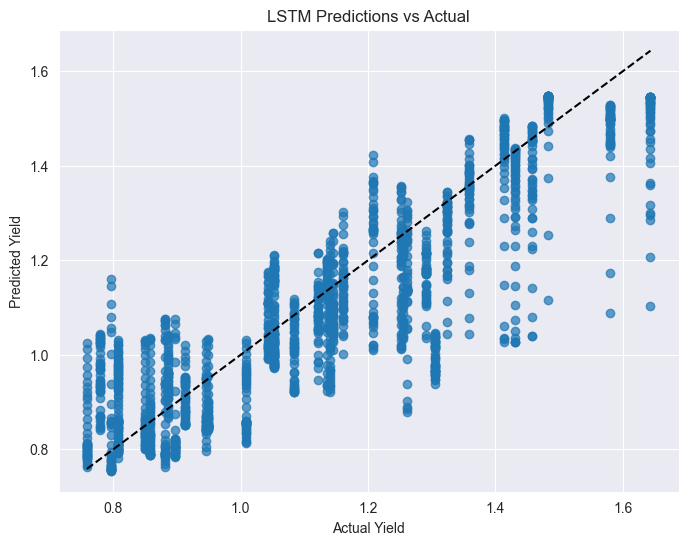

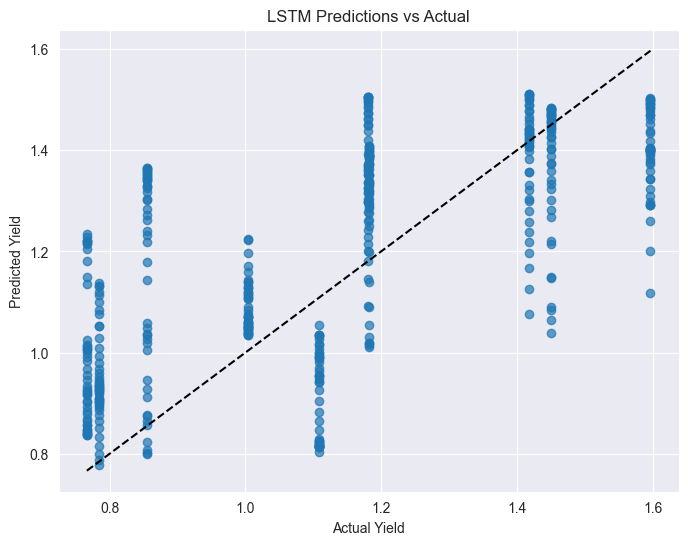

Train R²: 0.7399, Train MSE: 0.0149
Test R²: 0.4071, Test MSE: 0.0446


In [19]:
# from train_eval_functions import evaluate_model

best_model.load_state_dict(torch.load("best_model_hyper_param29.pth", map_location=device))

# Training metrics
r2_train, mse_train = evaluate_model(best_model, train_loader, output_variable_scaler=scaler_y, doInverseTransformScale = True,  plot_pred_vs_true=True)
# Test metrics
r2_test, mse_test = evaluate_model(best_model, test_loader, output_variable_scaler=scaler_y, doInverseTransformScale = True,  plot_pred_vs_true=True)

print(f'Train R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}')
print(f'Test R²: {r2_test:.4f}, Test MSE: {mse_test:.4f}')


In [ ]:
# save model
torch.save(best_model, "best_gru_models/best_model_full_4.pth")

# save Scalers for future predictions
import joblib

joblib.dump(scaler_X, "best_gru_models/scalers/scaler_X_4.save")
joblib.dump(scaler_y, "best_gru_models/scalers/scaler_y_4.save")